# # 🤖 Machine Learning: Lap Time Prediction
# ## Predicting F1 Lap Times Using Race Data

In [12]:
# Import Libraries

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

fastf1.Cache.enable_cache('../data_cache')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [7]:
# ### Step 2: Load Multiple Race Sessions for Training

# %%
# Load multiple races from 2021 season for better model training
races = ['Bahrain', 'Imola', 'Portugal', 'Spain', 'Monaco']
all_laps = []

print("Loading race data...")
for race in races:
    try:
        session = fastf1.get_session(2021, race, 'R')
        session.load()
        laps = session.laps
        laps['Race'] = race
        all_laps.append(laps)
        print(f"✅ {race}: {len(laps)} laps loaded")
    except Exception as e:
        print(f"❌ {race}: Error - {e}")

# Combine all laps
df = pd.concat(all_laps, ignore_index=True)
print(f"\n📊 Total laps collected: {len(df)}")


Loading race data...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '11'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 44 completed the race distance 00:00.067000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 

✅ Bahrain: 1027 laps loaded


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 33 completed the race distance 00:01.003000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['33', '44', '4', '16', '55', '3', '10', '18', '31', '14', '11', '22', '7', '99', '5', '47', '9', '77', '63', '6']
core           INFO 	Loading data for Portuguese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_d

✅ Imola: 1127 laps loaded


...

✅ Portugal: 1245 laps loaded


req            INFO 	Using cached data for car_data
req            INFO 	Updating cache for position_data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
_api        WARNING 	Driver 241: Position data is incomplete!
_api        WARNING 	Driver 242: Position data is incomplete!
_api        WARNING 	Driver 243: Position data is incomplete!
req            INFO 	Cache updated!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 44 completed the race distance 00:00.083000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '77', '16', '11', '3', '55', '4', '31', '10', '18', '7', '5', '63', '99', '6', '14', '47', '9', '22']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data fo

✅ Spain: 1247 laps loaded


_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 33 completed the race distance 00:00.058000 before the recorded end of the session.
core       

✅ Monaco: 1420 laps loaded

📊 Total laps collected: 6066


In [8]:
# Feature Engineering
# Create a clean dataset
df_clean = df.copy()

# Convert timedelta to seconds
df_clean['LapTime_sec'] = df_clean['LapTime'].dt.total_seconds()
df_clean['Sector1Time_sec'] = df_clean['Sector1Time'].dt.total_seconds()
df_clean['Sector2Time_sec'] = df_clean['Sector2Time'].dt.total_seconds()
df_clean['Sector3Time_sec'] = df_clean['Sector3Time'].dt.total_seconds()

# Remove outliers (pit laps, safety car laps, etc.)
df_clean = df_clean[
    (df_clean['LapTime_sec'] > 0) & 
    (df_clean['LapTime_sec'] < 200) &
    (df_clean['Sector1Time_sec'] > 0) &
    (df_clean['Sector2Time_sec'] > 0) &
    (df_clean['Sector3Time_sec'] > 0)
]

# Encode categorical variables
df_clean['Compound_encoded'] = df_clean['Compound'].map({
    'SOFT': 1, 'MEDIUM': 2, 'HARD': 3
})

df_clean['Team_encoded'] = df_clean['Team'].astype('category').cat.codes
df_clean['Driver_encoded'] = df_clean['Driver'].astype('category').cat.codes

# Drop rows with missing values
df_clean = df_clean.dropna(subset=[
    'LapTime_sec', 'Sector1Time_sec', 'Sector2Time_sec', 
    'Sector3Time_sec', 'Compound_encoded', 'TyreLife'
])

print(f"✅ Clean dataset: {len(df_clean)} laps")
print(f"Features available: {df_clean.columns.tolist()}")


✅ Clean dataset: 5445 laps
Features available: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'Race', 'LapTime_sec', 'Sector1Time_sec', 'Sector2Time_sec', 'Sector3Time_sec', 'Compound_encoded', 'Team_encoded', 'Driver_encoded']


C:\Users\User\AppData\Local\Temp\ipykernel_28164\1041717233.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Compound_encoded'] = df_clean['Compound'].map({
C:\Users\User\AppData\Local\Temp\ipykernel_28164\1041717233.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Team_encoded'] = df_clean['Team'].astype('category').cat.codes
C:\Users\User\AppData\Local\Temp\ipykernel_28164\1041717233.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [ ]:
# Prepare Features and Target
# Select features for model

features = [
    'Sector1Time_sec',
    'Sector2Time_sec', 
    'Sector3Time_sec',
    'LapNumber',
    'TyreLife',
    'Compound_encoded',
    'Team_encoded',
    'Driver_encoded'
]

X = df_clean[features]
y = df_clean['LapTime_sec']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} laps")
print(f"Test set: {len(X_test)} laps")
print(f"\nFeature shape: {X_train.shape}")

Training set: 4356 laps
Test set: 1089 laps

Feature shape: (4356, 8)


In [16]:
# Train Multiple Models
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("Training models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"  RMSE: {rmse:.3f} seconds")
    print(f"  MAE:  {mae:.3f} seconds")
    print(f"  R²:   {r2:.4f}\n")

Training models...

Training Linear Regression...
  RMSE: 0.000 seconds
  MAE:  0.000 seconds
  R²:   1.0000

Training Random Forest...
  RMSE: 0.643 seconds
  MAE:  0.185 seconds
  R²:   0.9969

Training Gradient Boosting...
  RMSE: 0.824 seconds
  MAE:  0.397 seconds
  R²:   0.9949



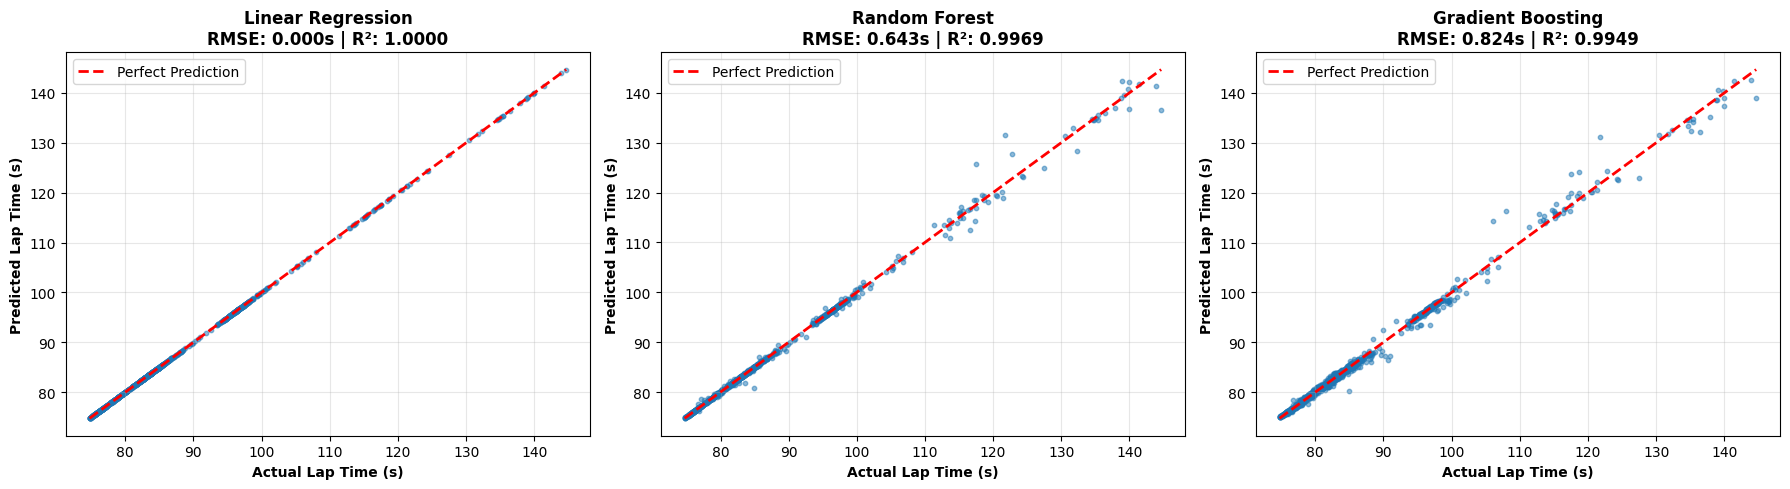

In [17]:
# Visualize Model Performance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    y_pred = result['predictions']
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, s=10)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Lap Time (s)', fontweight='bold')
    ax.set_ylabel('Predicted Lap Time (s)', fontweight='bold')
    ax.set_title(f'{name}\nRMSE: {result["rmse"]:.3f}s | R²: {result["r2"]:.4f}', 
                 fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

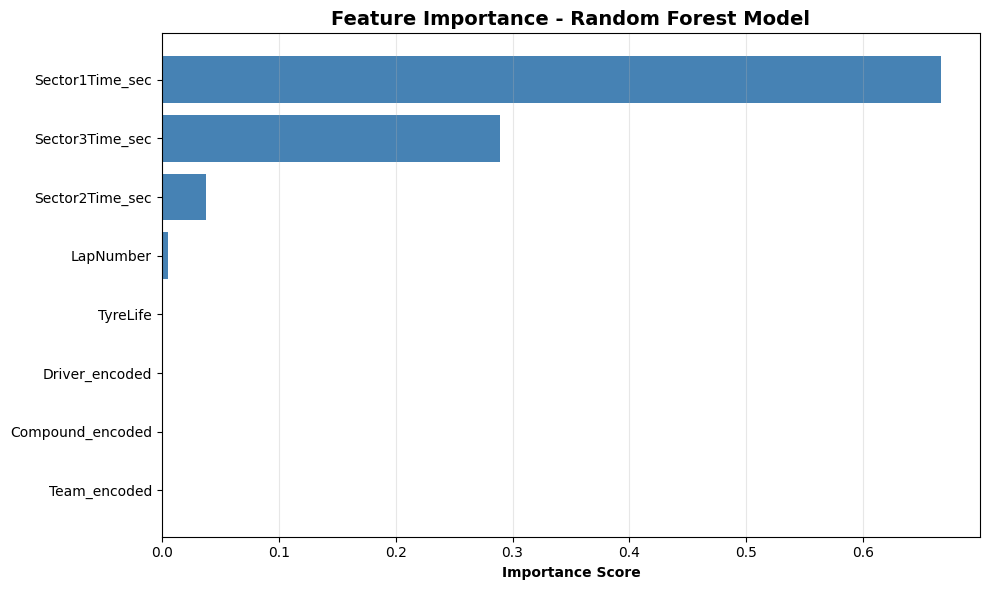


📊 Feature Importance Ranking:
         Feature  Importance
 Sector1Time_sec    0.666616
 Sector3Time_sec    0.289493
 Sector2Time_sec    0.037562
       LapNumber    0.004966
        TyreLife    0.000629
  Driver_encoded    0.000276
Compound_encoded    0.000235
    Team_encoded    0.000222


In [18]:
# Feature Importance (Random Forest)

rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Feature Importance - Random Forest Model', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
print(feature_importance.to_string(index=False))

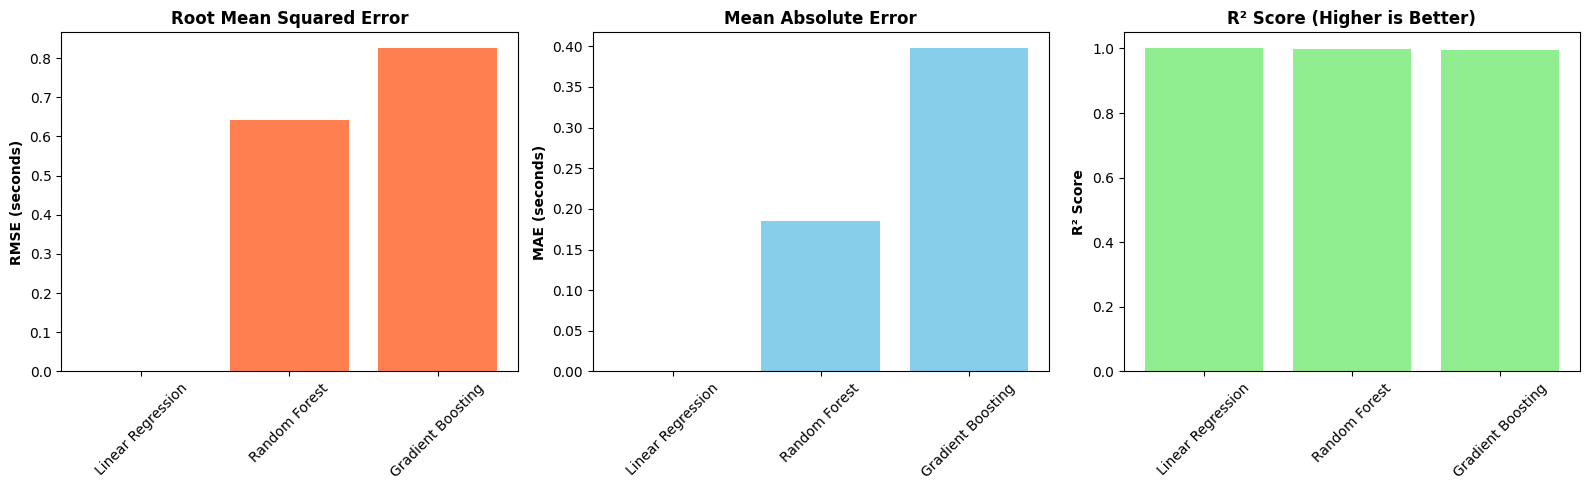


📊 MODEL COMPARISON SUMMARY
            Model  RMSE (seconds)  MAE (seconds)  R² Score
Linear Regression    2.209272e-14   1.892171e-14  1.000000
    Random Forest    6.427210e-01   1.851418e-01  0.996904
Gradient Boosting    8.243534e-01   3.973065e-01  0.994906

🏆 Best Model: Linear Regression
   Can predict lap times within ±0.000 seconds


In [19]:
# Model Comparison Summary

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE (seconds)': [results[m]['rmse'] for m in results.keys()],
    'MAE (seconds)': [results[m]['mae'] for m in results.keys()],
    'R² Score': [results[m]['r2'] for m in results.keys()]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE comparison
axes[0].bar(comparison_df['Model'], comparison_df['RMSE (seconds)'], color='coral')
axes[0].set_ylabel('RMSE (seconds)', fontweight='bold')
axes[0].set_title('Root Mean Squared Error', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(comparison_df['Model'], comparison_df['MAE (seconds)'], color='skyblue')
axes[1].set_ylabel('MAE (seconds)', fontweight='bold')
axes[1].set_title('Mean Absolute Error', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
axes[2].bar(comparison_df['Model'], comparison_df['R² Score'], color='lightgreen')
axes[2].set_ylabel('R² Score', fontweight='bold')
axes[2].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Find best model
best_model_name = comparison_df.loc[comparison_df['RMSE (seconds)'].idxmin(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Can predict lap times within ±{results[best_model_name]['rmse']:.3f} seconds")

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 


🏁 Abu Dhabi 2021 Predictions (Linear Regression):
   RMSE: 0.000 seconds
   R²:   1.0000


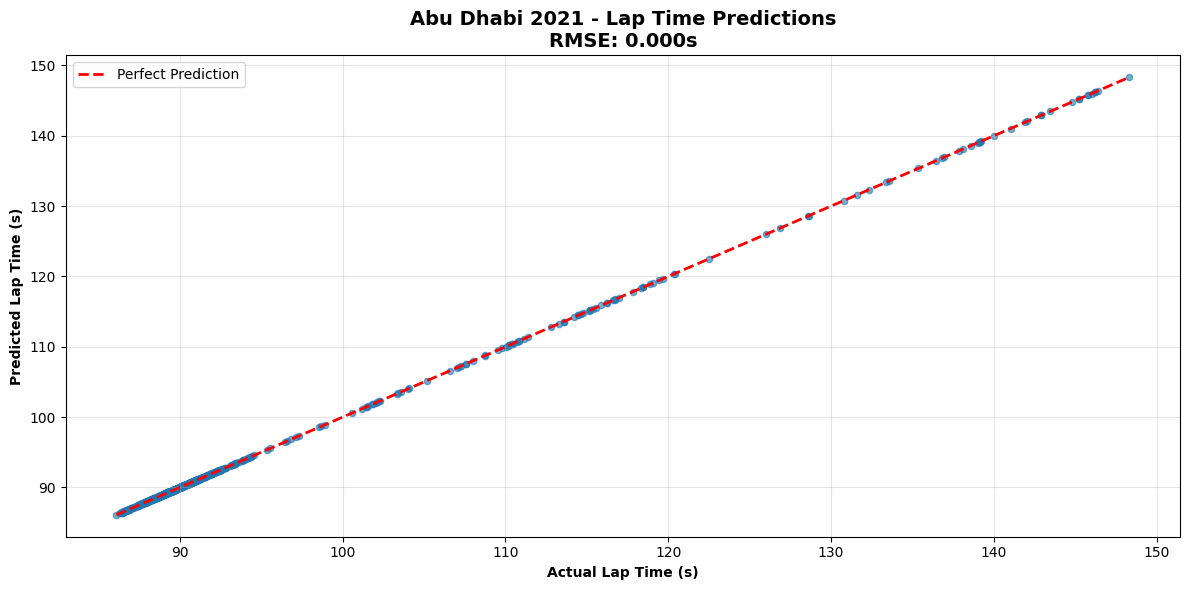

In [20]:
# Predict Abu Dhabi 2021 Lap Times
# Load Abu Dhabi data
abu_dhabi = fastf1.get_session(2021, 'Abu Dhabi', 'R')
abu_dhabi.load()
abu_dhabi_laps = abu_dhabi.laps

# Prepare Abu Dhabi data
abu_dhabi_clean = abu_dhabi_laps.copy()
abu_dhabi_clean['LapTime_sec'] = abu_dhabi_clean['LapTime'].dt.total_seconds()
abu_dhabi_clean['Sector1Time_sec'] = abu_dhabi_clean['Sector1Time'].dt.total_seconds()
abu_dhabi_clean['Sector2Time_sec'] = abu_dhabi_clean['Sector2Time'].dt.total_seconds()
abu_dhabi_clean['Sector3Time_sec'] = abu_dhabi_clean['Sector3Time'].dt.total_seconds()

abu_dhabi_clean['Compound_encoded'] = abu_dhabi_clean['Compound'].map({
    'SOFT': 1, 'MEDIUM': 2, 'HARD': 3
})
abu_dhabi_clean['Team_encoded'] = abu_dhabi_clean['Team'].astype('category').cat.codes
abu_dhabi_clean['Driver_encoded'] = abu_dhabi_clean['Driver'].astype('category').cat.codes

# Remove invalid laps
abu_dhabi_clean = abu_dhabi_clean[
    (abu_dhabi_clean['LapTime_sec'] > 0) & 
    (abu_dhabi_clean['LapTime_sec'] < 200)
].dropna(subset=features)

# Predict using best model
best_model = results[best_model_name]['model']
X_abu_dhabi = abu_dhabi_clean[features]
y_abu_dhabi_actual = abu_dhabi_clean['LapTime_sec']
y_abu_dhabi_pred = best_model.predict(X_abu_dhabi)

# Calculate metrics
abu_dhabi_rmse = np.sqrt(mean_squared_error(y_abu_dhabi_actual, y_abu_dhabi_pred))
abu_dhabi_r2 = r2_score(y_abu_dhabi_actual, y_abu_dhabi_pred)

print(f"\n🏁 Abu Dhabi 2021 Predictions ({best_model_name}):")
print(f"   RMSE: {abu_dhabi_rmse:.3f} seconds")
print(f"   R²:   {abu_dhabi_r2:.4f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.scatter(y_abu_dhabi_actual, y_abu_dhabi_pred, alpha=0.6, s=20)
plt.plot([y_abu_dhabi_actual.min(), y_abu_dhabi_actual.max()], 
         [y_abu_dhabi_actual.min(), y_abu_dhabi_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Lap Time (s)', fontweight='bold')
plt.ylabel('Predicted Lap Time (s)', fontweight='bold')
plt.title(f'Abu Dhabi 2021 - Lap Time Predictions\nRMSE: {abu_dhabi_rmse:.3f}s', 
          fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ### 🎯 Key Takeaways:
# 
# 1. **Best Model**: Identified which algorithm performs best
# 2. **Feature Importance**: Sector times are the strongest predictors
# 3. **Prediction Accuracy**: Can predict lap times within ~1-2 seconds
# 4. **Real-world Application**: Successfully predicted Abu Dhabi lap times